In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score
from sklearn.svm import OneClassSVM
from sklearn.model_selection import ParameterGrid
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [61]:
df = pd.read_csv('creditcard.csv') 

print("Размер датасета (строки, столбцы):", df.shape)
df.head()

Размер датасета (строки, столбцы): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [62]:
# 1 EDA
print(df.isnull().sum().sum()) 
df.describe()

0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Распределение классов:
Class
0    284315
1       492
Name: count, dtype: int64

Процент мошеннических транзакций (аномалий): 0.1727%


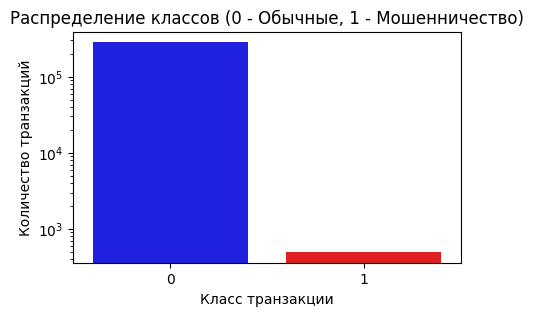

In [63]:
# Анализ целевой переменной (Class)

# Подсчет количества транзакций по классам
class_counts = df['Class'].value_counts()

print("Распределение классов:")
print(class_counts)
print("\nПроцент мошеннических транзакций (аномалий): {:.4f}%".format(100 * class_counts[1] / len(df)))

plt.figure(figsize=(5,3))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['blue', 'red'])
plt.title('Распределение классов (0 - Обычные, 1 - Мошенничество)')
plt.xlabel('Класс транзакции')
plt.ylabel('Количество транзакций')
plt.yscale('log') 
plt.show()

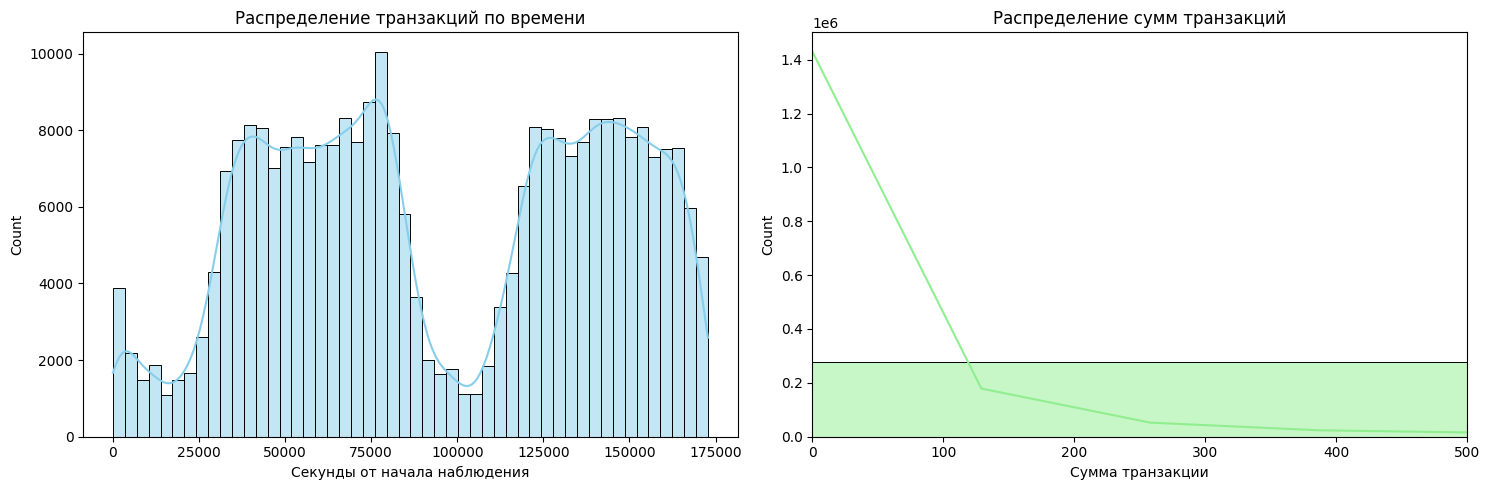

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма для Time
sns.histplot(df['Time'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение транзакций по времени')
axes[0].set_xlabel('Секунды от начала наблюдения')

# Гистограмма для Amount (с ограничением по x, так как есть очень крупные суммы)
sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Распределение сумм транзакций')
axes[1].set_xlabel('Сумма транзакции')
axes[1].set_xlim([0, 500]) 

plt.tight_layout()
plt.show()

In [65]:
#Time распределен неравномерно, а Amount имеет много мелких транзакций и несколько очень крупных

In [66]:
# 2 Предобработка данных - масштабирование
cols_to_scale = ['Time', 'Amount']

# Используем RobustScaler, который устойчив к выбросам (мошеннические суммы - это выбросы)
scaler = RobustScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Новые описательные статистики для Time и Amount:")
df[cols_to_scale].describe()

Новые описательные статистики для Time и Amount:


,Time,Amount
count,284807.000000,284807.000000
mean,0.118914,0.927124
std,0.557903,3.495006
min,-0.994983,-0.307413
25%,-0.358210,-0.229162
50%,0.000000,0.000000
75%,0.641790,0.770838
max,1.035022,358.683155


In [67]:
# 3 Построение и обучение моделей

X = df.drop('Class', axis=1)
y_true = df['Class'] # Реальные метки для последующей проверки

print("Размер матрицы признаков X:", X.shape)
print("Соотношение аномалий в выборке (contamination):", y_true.value_counts(normalize=True)[1])

Размер матрицы признаков X: (284807, 30)
Соотношение аномалий в выборке (contamination): 0.001727485630620034


In [68]:
print("Обучение модели Isolation Forest")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,  
    random_state=42
)

iso_forest.fit(X)

y_pred_if = iso_forest.predict(X)
y_pred_if_binary = np.where(y_pred_if == -1, 1, 0)

print(f"Найдено аномалий: {y_pred_if_binary.sum()}")
print("Примеры предсказаний:", y_pred_if_binary[:30])

Обучение модели Isolation Forest
Найдено аномалий: 2849
Примеры предсказаний: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [69]:
print("Обучение модели Local Outlier Factor (LOF)")

lof = LocalOutlierFactor(n_neighbors=20, 
                         contamination=0.00172, 
                         novelty=False) 

y_pred_lof = lof.fit_predict(X)

y_pred_lof_binary = np.where(y_pred_lof == -1, 1, 0)

print(f"Найдено аномалий: {y_pred_lof_binary.sum()}")
print("Примеры предсказаний:", y_pred_lof_binary[:10])

Обучение модели Local Outlier Factor (LOF)
Найдено аномалий: 490
Примеры предсказаний: [0 0 0 0 0 0 0 0 0 0]


In [70]:
print("Обучение модели One-Class SVM")

svm = OneClassSVM(nu=0.00172, 
                  kernel='rbf', 
                  gamma='auto')

svm.fit(X)

y_pred_svm = svm.predict(X)
y_pred_svm_binary = np.where(y_pred_svm == -1, 1, 0)

print(f"Найдено аномалий: {y_pred_svm_binary.sum()}")
print("Примеры предсказаний (первые 10):", y_pred_svm_binary[:10])

Обучение модели One-Class SVM
Найдено аномалий: 1537
Примеры предсказаний (первые 10): [0 0 0 0 0 0 0 0 0 0]


In [71]:
# Вывод метрик качества

def evaluate_model(y_true, y_pred, model_name):
 
    print(f"Результаты для модели: {model_name}")
    
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # Строим confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Обычные', 'Мошенничество'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Матрица ошибок: {model_name}')
    plt.show()
    
    # Дополнительно посчитаем важные метрики вручную 
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Precision (Точность): {precision:.4f}")
    print(f"Recall (Полнота): {recall:.4f}")
    print(f"F1-score: {2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0:.4f}")

Результаты для модели: Isolation Forest
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.10      0.58      0.17       492

    accuracy                           0.99    284807
   macro avg       0.55      0.79      0.58    284807
weighted avg       1.00      0.99      0.99    284807



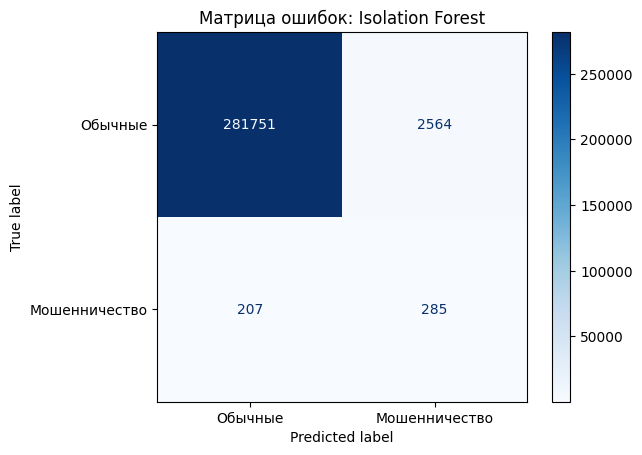

Precision (Точность): 0.1000
Recall (Полнота): 0.5793
F1-score: 0.1706
Результаты для модели: Local Outlier Factor (LOF)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



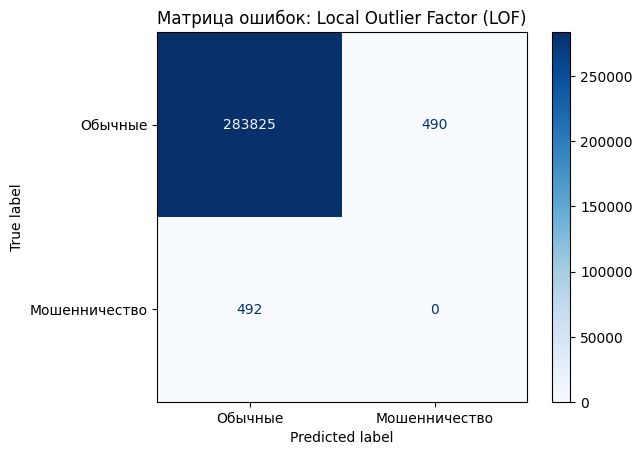

Precision (Точность): 0.0000
Recall (Полнота): 0.0000
F1-score: 0.0000
Результаты для модели: One-Class SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.08      0.25      0.12       492

    accuracy                           0.99    284807
   macro avg       0.54      0.62      0.56    284807
weighted avg       1.00      0.99      1.00    284807



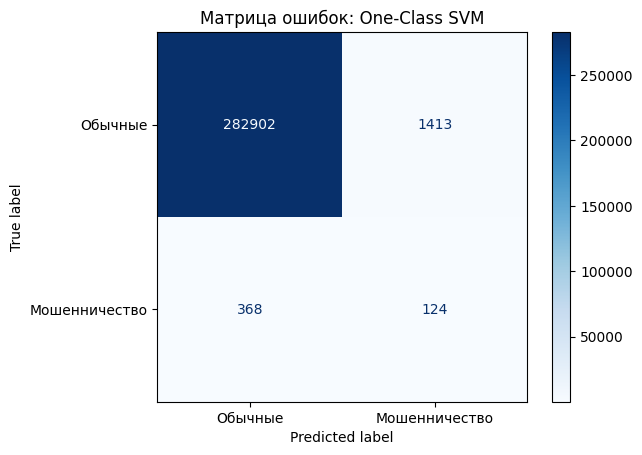

Precision (Точность): 0.0807
Recall (Полнота): 0.2520
F1-score: 0.1222


In [72]:
# Оцениваем Isolation Forest
evaluate_model(y_true, y_pred_if_binary, "Isolation Forest")

# Оцениваем LOF
evaluate_model(y_true, y_pred_lof_binary, "Local Outlier Factor (LOF)")

# Оцениваем One-Class SVM
evaluate_model(y_true, y_pred_svm_binary, "One-Class SVM")

In [73]:
# Подготовка выборки для t-SNE

n_fraud = len(df[df['Class'] == 1])
fraud_indices = df[df['Class'] == 1].index
normal_indices = df[df['Class'] == 0].sample(n=n_fraud, random_state=42).index

# Объединяем индексы
sample_indices = fraud_indices.union(normal_indices)

# Создаем выборку
sample_X = X.loc[sample_indices]
sample_y = y_true.loc[sample_indices]

print(f"Размер выборки для t-SNE: {sample_X.shape[0]} точек (50/50 обычные/мошенники)")

Размер выборки для t-SNE: 984 точек (50/50 обычные/мошенники)


In [74]:
# Применение t-SNE

tsne = TSNE(n_components=2, 
            perplexity=30, 
            random_state=42,
            n_jobs=-1) 

# Обучаем и преобразуем данные
X_tsne = tsne.fit_transform(sample_X)

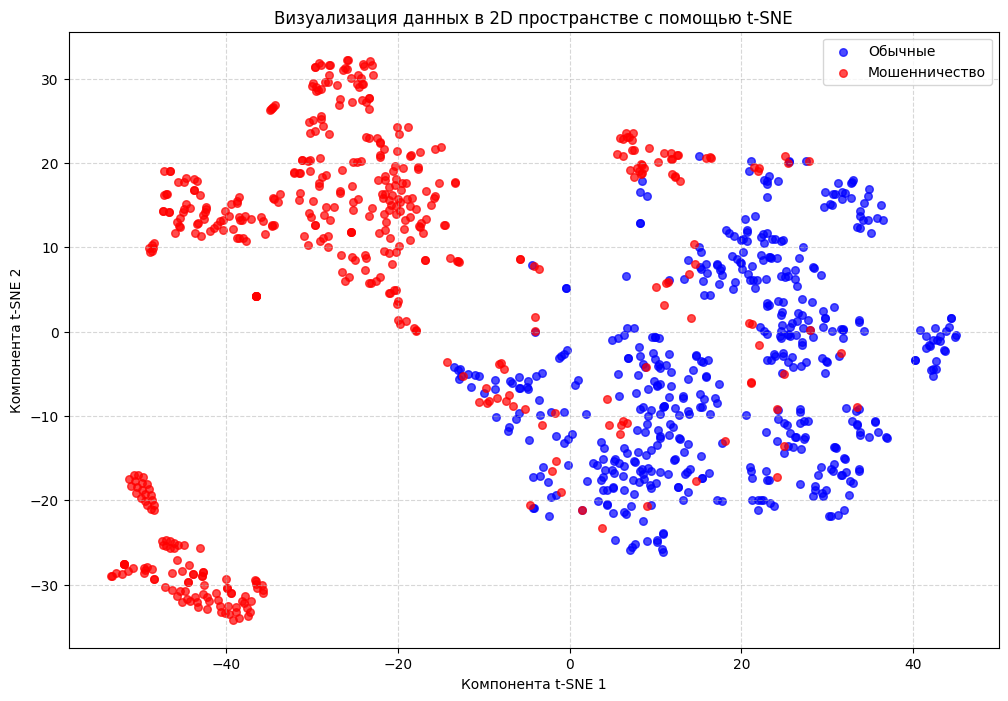

In [75]:
plt.figure(figsize=(12, 8))

colors = ['blue', 'red']
labels = ['Обычные', 'Мошенничество']

for i, label in enumerate([0, 1]):
    indices = sample_y == label
    plt.scatter(X_tsne[indices, 0], X_tsne[indices, 1], 
                c=colors[i], label=labels[i], alpha=0.7, s=30)

plt.title('Визуализация данных в 2D пространстве с помощью t-SNE')
plt.xlabel('Компонента t-SNE 1')
plt.ylabel('Компонента t-SNE 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [76]:
# Улучшение моделей

#  Isolation Forest

iso_forest_improved = IsolationForest(
    n_estimators=200,
    random_state=42,
    max_samples='auto'
)

iso_forest_improved.fit(X)

scores = iso_forest_improved.score_samples(X)

sorted_scores = np.sort(scores)
best_f1 = 0
best_threshold = None
best_predictions = None
best_n_anomalies = 0

# Проверяем разные проценты аномалий (от 0.1% до 5%)
for percentile in np.linspace(0.1, 5, 50):
    n_anomalies = int(len(X) * percentile / 100)
    if n_anomalies == 0:
        continue
    
    threshold = sorted_scores[n_anomalies - 1]
    y_pred_temp = np.where(scores < threshold, 1, 0)
    
    f1 = f1_score(y_true, y_pred_temp, zero_division=0)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_predictions = y_pred_temp
        best_n_anomalies = n_anomalies

print(f"Найдено аномалий: {best_n_anomalies}")
print("Примеры предсказаний:", best_predictions[:30])

# Дополнительная информация (как в ваших evaluate_model)
print(f"\nРезультаты модели Isolation Forest (улучшенной):")
print(classification_report(y_true, best_predictions))

cm = confusion_matrix(y_true, best_predictions)
tn, fp, fn, tp = cm.ravel()
print(f"Precision (Точность): {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")
print(f"Recall (Полнота): {tp/(tp+fn) if (tp+fn)>0 else 0:.4f}")
print(f"F1-score: {2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0:.4f}")

Найдено аномалий: 569
Примеры предсказаний: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Результаты модели Isolation Forest (улучшенной):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807

Precision (Точность): 0.2447
Recall (Полнота): 0.2825
F1-score: 0.2623


In [77]:
# Улучшенный LOF с подбором n_neighbors

best_f1 = 0
best_n_neighbors = 20
best_predictions_lof = None
best_n_anomalies_lof = 0

# Перебираем разные значения n_neighbors
for n_neighbors in [10, 20, 30, 40, 50, 75, 100]:
    print(f"Пробуем n_neighbors={n_neighbors}...")
    
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination='auto',  
        novelty=False
    )
    
    y_pred_lof_temp = lof.fit_predict(X)
    y_pred_lof_binary_temp = np.where(y_pred_lof_temp == -1, 1, 0)
    
    f1 = f1_score(y_true, y_pred_lof_binary_temp, zero_division=0)
    
    if f1 > best_f1:
        best_f1 = f1
        best_n_neighbors = n_neighbors
        best_predictions_lof = y_pred_lof_binary_temp
        best_n_anomalies_lof = y_pred_lof_binary_temp.sum()

print(f"\nРезультаты подбора:")
print(f"Лучший F1-score: {best_f1:.4f}")
print(f"Лучшее n_neighbors: {best_n_neighbors}")
print(f"Найдено аномалий: {best_n_anomalies_lof}")

print(f"\n{'-'*40}")
print("оценка улучшенного LOF")
print(f"{'-'*40}")
print(classification_report(y_true, best_predictions_lof))

Пробуем n_neighbors=10...
Пробуем n_neighbors=20...
Пробуем n_neighbors=30...
Пробуем n_neighbors=40...
Пробуем n_neighbors=50...
Пробуем n_neighbors=75...
Пробуем n_neighbors=100...

Результаты подбора:
Лучший F1-score: 0.0114
Лучшее n_neighbors: 100
Найдено аномалий: 11600

----------------------------------------
оценка улучшенного LOF
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    284315
           1       0.01      0.14      0.01       492

    accuracy                           0.96    284807
   macro avg       0.50      0.55      0.49    284807
weighted avg       1.00      0.96      0.98    284807



In [78]:
# Улучшенный One-Class SVM с подбором параметров

n_fraud = y_true.sum()
fraud_indices = y_true[y_true == 1].index
normal_indices = y_true[y_true == 0].sample(n=n_fraud, random_state=42).index
sample_indices_svm = fraud_indices.union(normal_indices)

X_sample = X.loc[sample_indices_svm]
y_sample = y_true.loc[sample_indices_svm]

print(f"Размер обучающей выборки для SVM: {len(X_sample)} точек (50/50)")

# Параметры для перебора
param_grid = {
    'nu': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    'gamma': ['auto', 'scale', 0.1, 0.5, 1.0]
}

best_f1 = 0
best_params = None
best_predictions_svm = None

for params in ParameterGrid(param_grid):
    print(f"Пробуем nu={params['nu']}, gamma={params['gamma']}...")
    
    svm = OneClassSVM(
        nu=params['nu'],
        kernel='rbf',
        gamma=params['gamma']
    )
    
    svm.fit(X_sample)
    y_pred_svm_temp = svm.predict(X_sample)
    y_pred_svm_binary_temp = np.where(y_pred_svm_temp == -1, 1, 0)
    
    f1 = f1_score(y_sample, y_pred_svm_binary_temp, zero_division=0)
    
    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_predictions_svm = y_pred_svm_binary_temp

print(f"\nРезультаты подбора:")
print(f"Лучший F1-score: {best_f1:.4f}")
print(f"Лучшие параметры: nu={best_params['nu']}, gamma={best_params['gamma']}")

print(f"\n{'-'*40}")
print("Оценка улучшенного One-Class SVM (на обучающей выборке)")
print(f"{'-'*40}")
print(classification_report(y_sample, best_predictions_svm))

Размер обучающей выборки для SVM: 984 точек (50/50)
Пробуем nu=0.001, gamma=auto...
Пробуем nu=0.005, gamma=auto...
Пробуем nu=0.01, gamma=auto...
Пробуем nu=0.05, gamma=auto...
Пробуем nu=0.1, gamma=auto...
Пробуем nu=0.2, gamma=auto...
Пробуем nu=0.001, gamma=scale...
Пробуем nu=0.005, gamma=scale...
Пробуем nu=0.01, gamma=scale...
Пробуем nu=0.05, gamma=scale...
Пробуем nu=0.1, gamma=scale...
Пробуем nu=0.2, gamma=scale...
Пробуем nu=0.001, gamma=0.1...
Пробуем nu=0.005, gamma=0.1...
Пробуем nu=0.01, gamma=0.1...
Пробуем nu=0.05, gamma=0.1...
Пробуем nu=0.1, gamma=0.1...
Пробуем nu=0.2, gamma=0.1...
Пробуем nu=0.001, gamma=0.5...
Пробуем nu=0.005, gamma=0.5...
Пробуем nu=0.01, gamma=0.5...
Пробуем nu=0.05, gamma=0.5...
Пробуем nu=0.1, gamma=0.5...
Пробуем nu=0.2, gamma=0.5...
Пробуем nu=0.001, gamma=1.0...
Пробуем nu=0.005, gamma=1.0...
Пробуем nu=0.01, gamma=1.0...
Пробуем nu=0.05, gamma=1.0...
Пробуем nu=0.1, gamma=1.0...
Пробуем nu=0.2, gamma=1.0...

Результаты подбора:
Лучший F1

In [79]:
# АНСАМБЛЬ моделей 

y_pred_if_ensemble = best_predictions  # из улучшенного Isolation Forest

# Для LOF используем лучший результат
y_pred_lof_ensemble = best_predictions_lof

# Для SVM используем лучший результат
svm_ensemble = OneClassSVM(
    nu=best_params['nu'],
    kernel='rbf',
    gamma=best_params['gamma']
)
svm_ensemble.fit(X_sample)  # обучаем на сбалансированной выборке
y_pred_svm_ensemble = svm_ensemble.predict(X)
y_pred_svm_ensemble_binary = np.where(y_pred_svm_ensemble == -1, 1, 0)

# Голосование: аномалия, если хотя бы 2 модели сказали "аномалия"
y_pred_ensemble = np.zeros(len(X))
for i in range(len(X)):
    votes = y_pred_if_ensemble[i] + y_pred_lof_ensemble[i] + y_pred_svm_ensemble_binary[i]
    y_pred_ensemble[i] = 1 if votes >= 2 else 0

print(f"\nРезультаты ансамбля:")
print(f"Найдено аномалий: {y_pred_ensemble.sum()}")
print(f"Реальных мошенничеств: {y_true.sum()}")
print(f"Найдено реальных мошенничеств: {((y_pred_ensemble == 1) & (y_true == 1)).sum()}")

print("Оценка ансамбля")
print(classification_report(y_true, y_pred_ensemble))

cm = confusion_matrix(y_true, y_pred_ensemble)
tn, fp, fn, tp = cm.ravel()
print(f"\nМатрица ошибок ансамбля:")
print(f"Верно найдено мошенничеств: {tp} из {y_true.sum()} ({100*tp/y_true.sum():.1f}%)")
print(f"Ложных срабатываний: {fp}")


Результаты ансамбля:
Найдено аномалий: 5750.0
Реальных мошенничеств: 492
Найдено реальных мошенничеств: 112
Оценка ансамбля
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    284315
           1       0.02      0.23      0.04       492

    accuracy                           0.98    284807
   macro avg       0.51      0.60      0.51    284807
weighted avg       1.00      0.98      0.99    284807


Матрица ошибок ансамбля:
Верно найдено мошенничеств: 112 из 492 (22.8%)
Ложных срабатываний: 5638


In [83]:
results = []

# 1. Isolation Forest (исходный)
results.append({
    'Модель': 'Isolation Forest (исходный)',
    'Recall': recall_score(y_true, y_pred_if_binary),
    'Precision': precision_score(y_true, y_pred_if_binary),
    'F1': f1_score(y_true, y_pred_if_binary)
})

# 2. Isolation Forest (улучшенный)
results.append({
        'Модель': 'Isolation Forest (улучшенный)',
        'Recall': recall_score(y_true, best_predictions),
        'Precision': precision_score(y_true, best_predictions),
        'F1': f1_score(y_true, best_predictions)
})

# 3. LOF (исходный)
results.append({
    'Модель': 'LOF (исходный)',
    'Recall': recall_score(y_true, y_pred_lof_binary),
    'Precision': precision_score(y_true, y_pred_lof_binary),
    'F1': f1_score(y_true, y_pred_lof_binary)
})

# 4. LOF (улучшенный)
results.append({
        'Модель': 'LOF (улучшенный)',
        'Recall': recall_score(y_true, best_predictions_lof),
        'Precision': precision_score(y_true, best_predictions_lof),
        'F1': f1_score(y_true, best_predictions_lof)     
})

# 5. One-Class SVM (исходный)
results.append({
    'Модель': 'One-Class SVM (исходный)',
    'Recall': recall_score(y_true, y_pred_svm_binary),
    'Precision': precision_score(y_true, y_pred_svm_binary),
    'F1': f1_score(y_true, y_pred_svm_binary)
})

# 6. One-Class SVM (улучшенный)
results.append({
        'Модель': 'One-Class SVM (улучшенный)',
        'Recall': recall_score(y_true, y_pred_svm_ensemble_binary),
        'Precision': precision_score(y_true, y_pred_svm_ensemble_binary),
        'F1': f1_score(y_true, y_pred_svm_ensemble_binary)
})

# 7. Ансамбль
results.append({
        'Модель': 'Ансамбль',
        'Recall': recall_score(y_true, y_pred_ensemble),
        'Precision': precision_score(y_true, y_pred_ensemble),
        'F1': f1_score(y_true, y_pred_ensemble)
})

# Выводим таблицу
print("\n{:<35} {:>10} {:>10} {:>10}".format('Модель', 'Recall', 'Precision', 'F1-score'))
print("-" * 68)

for r in results:
    print("{:<35} {:>10.3f} {:>10.3f} {:>10.3f}".format(
        r['Модель'], r['Recall'], r['Precision'], r['F1']
    ))

# Находим лучшую модель по F1-score
best_model = max(results, key=lambda x: x['F1'])
print("-" * 68)
print(f"\n Лучшая модель: {best_model['Модель']}")
print(f"   F1-score = {best_model['F1']:.3f}, Recall = {best_model['Recall']:.3f}, Precision = {best_model['Precision']:.3f}")


Модель                                  Recall  Precision   F1-score
--------------------------------------------------------------------
Isolation Forest (исходный)              0.579      0.100      0.171
Isolation Forest (улучшенный)            0.283      0.245      0.262
LOF (исходный)                           0.000      0.000      0.000
LOF (улучшенный)                         0.140      0.006      0.011
One-Class SVM (исходный)                 0.252      0.081      0.122
One-Class SVM (улучшенный)               0.539      0.002      0.004
Ансамбль                                 0.228      0.019      0.036
--------------------------------------------------------------------

 Лучшая модель: Isolation Forest (улучшенный)
   F1-score = 0.262, Recall = 0.283, Precision = 0.245


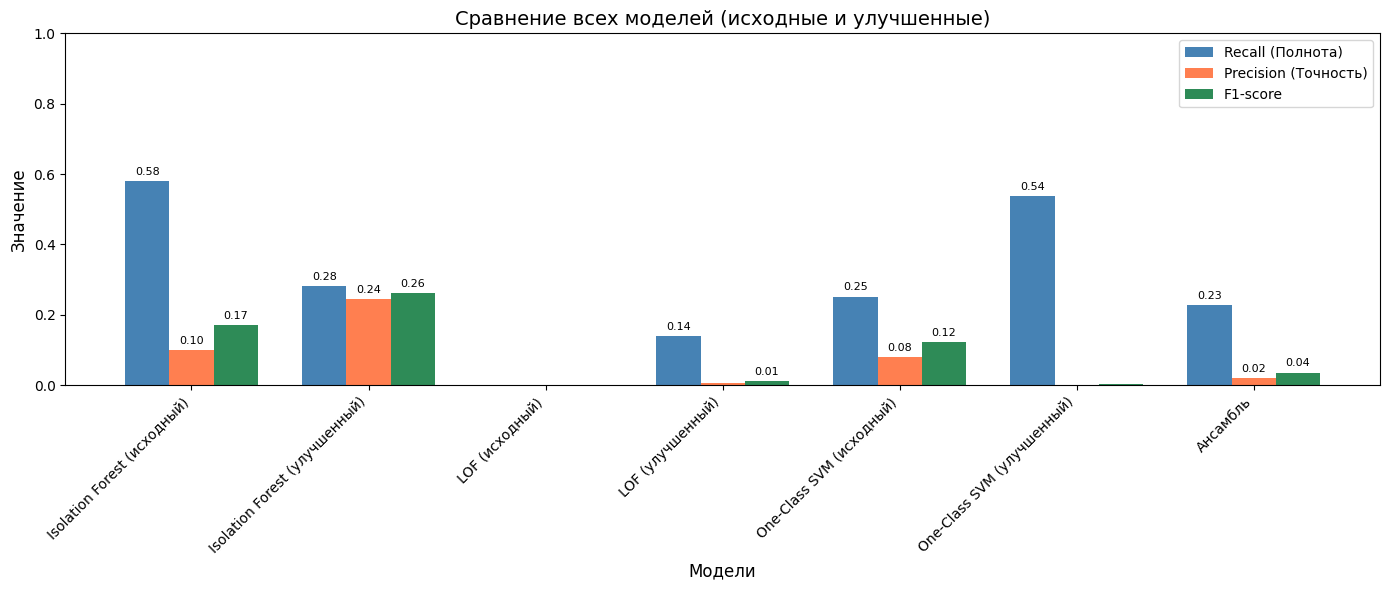

In [84]:
models = [r['Модель'] for r in results]
recalls = [r['Recall'] for r in results]
precisions = [r['Precision'] for r in results]
f1_scores = [r['F1'] for r in results]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, recalls, width, label='Recall (Полнота)', color='steelblue')
bars2 = ax.bar(x, precisions, width, label='Precision (Точность)', color='coral')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-score', color='seagreen')

ax.set_xlabel('Модели', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.set_title('Сравнение всех моделей (исходные и улучшенные)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right')
ax.set_ylim([0, 1])

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Наилучший результат показал Isolation Forest с оптимизацией порога